In [2]:
import pandas as pd
import numpy as np

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# ML
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("MIDWEST.csv")

df.head()

,RespondentID,"In your own words, what would you call the part of the country you live in now?","How much, if at all, do you personally identify as a Midwesterner?",Unnamed: 3,Unnamed: 4,Unnamed: 5,Which of the following states do you consider part of the Midwest? Please select all that apply.,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 43,Location (Census Region),Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,NaN,Open-Ended Response,A lot,Some,Not much,Not at all,Illinois,Indiana,Iowa,Kansas,...,Graduate degree,New England,Middle Atlantic,East North Central,West North Central,South Atlantic,East South Central,West South Central,Mountain,Pacific
1,3.126807e+09,Southern,NaN,NaN,Not much,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West South Central,NaN,NaN
2,3.126802e+09,Midwest,A lot,NaN,NaN,NaN,Illinois,Indiana,Iowa,Kansas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.126791e+09,Midwest,NaN,NaN,Not much,NaN,Illinois,NaN,Iowa,NaN,...,NaN,NaN,NaN,East North Central,NaN,NaN,NaN,NaN,NaN,NaN
4,3.126781e+09,Mid-west,A lot,NaN,NaN,NaN,Illinois,Indiana,NaN,NaN,...,NaN,NaN,NaN,East North Central,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2779 entries, 0 to 2778
Data columns (total 53 columns):
 #   Column                                                                                             Non-Null Count  Dtype  
---  ------                                                                                             --------------  -----  
 0   RespondentID                                                                                       2778 non-null   float64
 1   In your own words, what would you call the part of the country you live in now?                    2778 non-null   str    
 2   How much, if at all, do you personally identify as a Midwesterner?                                 771 non-null    str    
 3   Unnamed: 3                                                                                         588 non-null    str    
 4   Unnamed: 4                                                                                         347 non-null    str    
 5   Unn

RespondentID                                                                                            1
In your own words, what would you call the part of the country you live in now?                         1
How much, if at all, do you personally identify as a Midwesterner?                                   2008
Unnamed: 3                                                                                           2191
Unnamed: 4                                                                                           2432
Unnamed: 5                                                                                           1703
Which of the following states do you consider part of the Midwest? Please select all that apply.      824
Unnamed: 7                                                                                            953
Unnamed: 8                                                                                            792
Unnamed: 9                                    

In [6]:
df.head()

,RespondentID,"In your own words, what would you call the part of the country you live in now?","How much, if at all, do you personally identify as a Midwesterner?",Unnamed: 3,Unnamed: 4,Unnamed: 5,Which of the following states do you consider part of the Midwest? Please select all that apply.,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 43,Location (Census Region),Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51,Unnamed: 52
0,NaN,Open-Ended Response,A lot,Some,Not much,Not at all,Illinois,Indiana,Iowa,Kansas,...,Graduate degree,New England,Middle Atlantic,East North Central,West North Central,South Atlantic,East South Central,West South Central,Mountain,Pacific
1,3.126807e+09,Southern,NaN,NaN,Not much,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West South Central,NaN,NaN
2,3.126802e+09,Midwest,A lot,NaN,NaN,NaN,Illinois,Indiana,Iowa,Kansas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.126791e+09,Midwest,NaN,NaN,Not much,NaN,Illinois,NaN,Iowa,NaN,...,NaN,NaN,NaN,East North Central,NaN,NaN,NaN,NaN,NaN,NaN
4,3.126781e+09,Mid-west,A lot,NaN,NaN,NaN,Illinois,Indiana,NaN,NaN,...,NaN,NaN,NaN,East North Central,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns = df.columns.str.strip()

In [9]:
print(df.head())

   RespondentID  \
0           NaN   
1  3.126807e+09   
2  3.126802e+09   
3  3.126791e+09   
4  3.126781e+09   

  In your own words, what would you call the part of the country you live in now?  \
0                                Open-Ended Response                                
1                                           Southern                                
2                                            Midwest                                
3                                            Midwest                                
4                                           Mid-west                                

  How much, if at all, do you personally identify as a Midwesterner?  \
0                                              A lot                   
1                                                NaN                   
2                                              A lot                   
3                                                NaN                   
4             

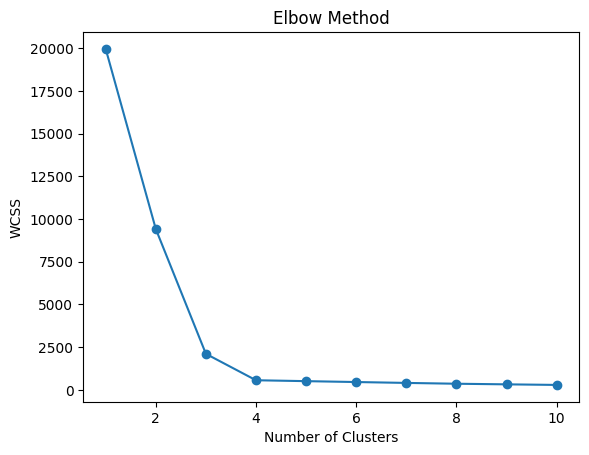

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# sample data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
print(df.shape)
print(X.shape)

(2779, 53)
(300, 2)


In [17]:
df.columns.tolist()

['RespondentID',
 'In your own words, what would you call the part of the country you live in now?',
 'How much, if at all, do you personally identify as a Midwesterner?',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Which of the following states do you consider part of the Midwest? Please select all that apply.',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'Unnamed: 18',
 'Unnamed: 19',
 'Unnamed: 20',
 'Unnamed: 21',
 'Unnamed: 22',
 'Unnamed: 23',
 'Unnamed: 24',
 'Unnamed: 25',
 'In what ZIP code is your home located? (enter 5-digit ZIP code; for example, 00544 or 94305)',
 'Gender',
 'Unnamed: 28',
 'Age',
 'Unnamed: 30',
 'Unnamed: 31',
 'Unnamed: 32',
 'Unnamed: 33',
 'Household Income',
 'Unnamed: 35',
 'Unnamed: 36',
 'Unnamed: 37',
 'Unnamed: 38',
 'Education',
 'Unnamed: 40',
 'Unnamed: 41',
 'Unnamed: 42',
 'Unnamed: 43',
 'Location (Census Reg

In [19]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(300, 2)
